<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №6: Синтез цифровых фильтров (КИХ и БИХ)

## Часть 1. Синтез КИХ-фильтров методом окон

### Задание 1.1. Проектирование ФНЧ с разными окнами
Спроектируйте КИХ-ФНЧ с частотой среза 200 Гц (частота дискретизации 1000 Гц), длина фильтра 51 отсчёт. Используйте окна:
- прямоугольное,
- Ханна,
- Хемминга,
- Блэкмана.

Постройте на одном графике АЧХ (в дБ) всех четырёх фильтров. Сравните:
- крутизну среза,
- уровень пульсаций в полосе пропускания и заграждения,
- ширину переходной полосы.


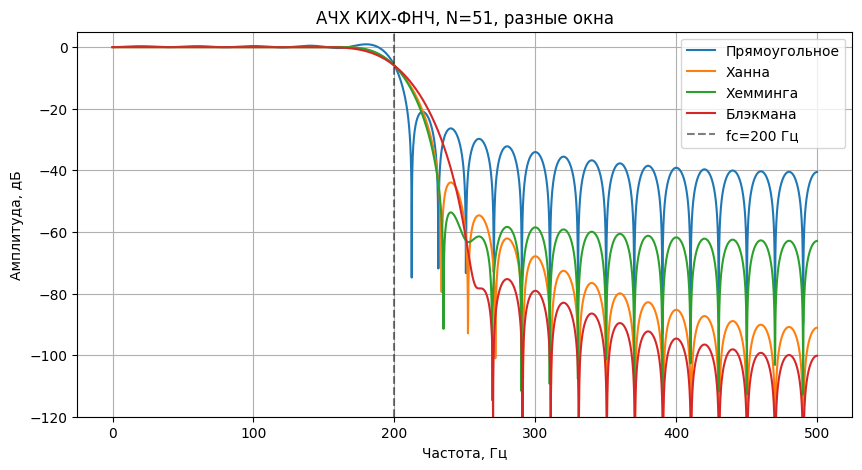

Прямоугольное  : подавление после 300 Гц ≈ 34.1 дБ
Ханна          : подавление после 300 Гц ≈ 67.9 дБ
Хемминга       : подавление после 300 Гц ≈ 58.5 дБ
Блэкмана       : подавление после 300 Гц ≈ 79.1 дБ


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

fs = 1000
fc = 200

def plot_response(b, a=1, fs=1000, label=None, db=True, worN=4096):
    w, h = signal.freqz(b, a, worN=worN, fs=fs)
    y = np.abs(h)
    if db:
        y = 20 * np.log10(np.maximum(y, 1e-8))
    plt.plot(w, y, label=label)
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда, дБ' if db else 'Амплитуда')
    return w, h

def spectrum(x, fs):
    f = np.fft.rfftfreq(len(x), 1 / fs)
    X = np.abs(np.fft.rfft(x)) * 2 / len(x)
    return f, X

def amp_at(x, fs, f0):
    f, X = spectrum(x, fs)
    return X[np.argmin(np.abs(f - f0))]

N = 51
windows = {
    'Прямоугольное': 'boxcar',
    'Ханна': 'hann',
    'Хемминга': 'hamming',
    'Блэкмана': 'blackman'
}

filters_11 = {}
plt.figure()
for name, win in windows.items():
    h = signal.firwin(N, fc, window=win, fs=fs)
    filters_11[name] = h
    plot_response(h, fs=fs, label=name)

plt.axvline(fc, color='k', linestyle='--', alpha=0.5, label='fc=200 Гц')
plt.title('АЧХ КИХ-ФНЧ, N=51, разные окна')
plt.ylim(-120, 5)
plt.legend()
plt.show()

# Численная оценка подавления в полосе заграждения, начиная с 300 Гц
for name, h in filters_11.items():
    w, H = signal.freqz(h, worN=4096, fs=fs)
    stop_max = np.max(np.abs(H[w >= 300]))
    att = -20 * np.log10(stop_max)
    print(f'{name:15s}: подавление после 300 Гц ≈ {att:.1f} дБ')

**Вопросы:** Какое окно обеспечивает наилучшее подавление в полосе заграждения? Какое – самую крутую переходную полосу? Как это связано с формой окна?

Лучшее подавление в полосе заграждения даёт окно Блэкмана: у него самые низкие боковые лепестки, поэтому высокочастотная часть сильнее подавляется. Самая узкая переходная область получается у прямоугольного окна, то есть срез у него самый крутой, но за это приходится платить большими пульсациями и плохим подавлением. Связь такая: чем сильнее окно сглаживает края импульсной характеристики, тем меньше боковые лепестки, но тем шире главный лепесток и переходная полоса.

### Задание 1.2. Влияние длины фильтра
Для окна Хемминга спроектируйте ФНЧ с fc=200 Гц, fs=1000 Гц, с длинами 21, 51, 101. Постройте АЧХ на одном графике.


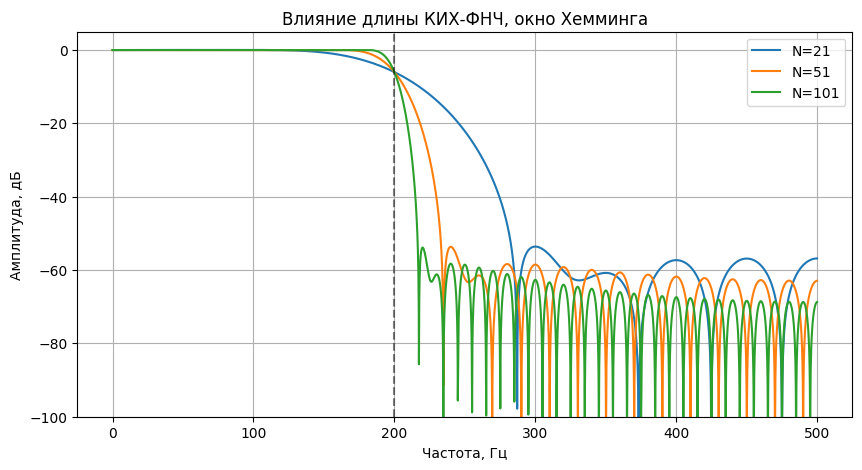

In [3]:
lengths = [21, 51, 101]
plt.figure()
for N in lengths:
    h = signal.firwin(N, fc, window='hamming', fs=fs)
    plot_response(h, fs=fs, label=f'N={N}')

plt.axvline(fc, color='k', linestyle='--', alpha=0.5)
plt.title('Влияние длины КИХ-ФНЧ, окно Хемминга')
plt.ylim(-100, 5)
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины влияет на крутизну среза и на уровень боковых лепестков?

При увеличении длины КИХ-фильтра переходная полоса становится уже, поэтому срез получается более резким. Уровень боковых лепестков в основном определяется выбранным окном, поэтому сам по себе рост длины не всегда сильно меняет их максимальную высоту, но делает частотную характеристику более точной и «узкой» около границы полосы.


### Задание 1.3. Синтез ФВЧ и полосового фильтра методом окон
Используя тот же оконный метод, спроектируйте:
- ФВЧ с fc=200 Гц (длина 51, окно Хемминга);
- полосовой фильтр с полосой пропускания 200–300 Гц (длина 51, окно Хемминга).

Постройте АЧХ обоих фильтров.


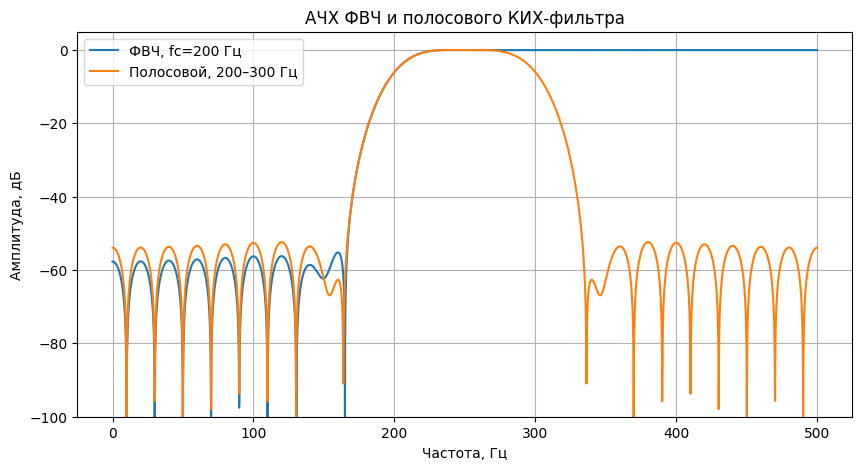

In [4]:
N = 51
h_hp = signal.firwin(N, fc, window='hamming', fs=fs, pass_zero=False)
h_bp = signal.firwin(N, [200, 300], window='hamming', fs=fs, pass_zero=False)

plt.figure()
plot_response(h_hp, fs=fs, label='ФВЧ, fc=200 Гц')
plot_response(h_bp, fs=fs, label='Полосовой, 200–300 Гц')
plt.title('АЧХ ФВЧ и полосового КИХ-фильтра')
plt.ylim(-100, 5)
plt.legend()
plt.show()

Подайте на спроектированные фильтры сигнал: сумма синусоид 100, 250 и 350 Гц (амплитуды 1, 0.8, 0.6). Постройте спектры до и после фильтрации (в логарифмическом масштабе).

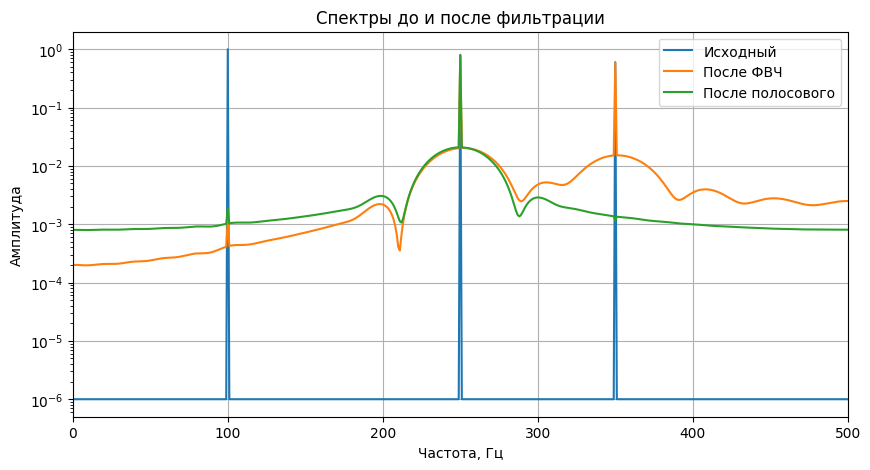

Исходный
  100 Гц: 1.000
  250 Гц: 0.800
  350 Гц: 0.600
ФВЧ
  100 Гц: 0.001
  250 Гц: 0.780
  350 Гц: 0.585
Полосовой
  100 Гц: 0.002
  250 Гц: 0.779
  350 Гц: 0.001


In [5]:
t = np.arange(0, 1, 1 / fs)
x = (np.sin(2*np.pi*100*t) +
     0.8*np.sin(2*np.pi*250*t) +
     0.6*np.sin(2*np.pi*350*t))

y_hp = signal.lfilter(h_hp, [1], x)
y_bp = signal.lfilter(h_bp, [1], x)

plt.figure()
for sig, name in [(x, 'Исходный'), (y_hp, 'После ФВЧ'), (y_bp, 'После полосового')]:
    f, X = spectrum(sig, fs)
    plt.semilogy(f, np.maximum(X, 1e-6), label=name)
plt.title('Спектры до и после фильтрации')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 500)
plt.legend()
plt.show()

for name, sig in [('Исходный', x), ('ФВЧ', y_hp), ('Полосовой', y_bp)]:
    print(name)
    for f0 in [100, 250, 350]:
        print(f'  {f0} Гц: {amp_at(sig, fs, f0):.3f}')

**Вопрос:** Объясните полученные результаты.

Фильтр верхних частот подавляет низкую частоту 100 Гц, а компоненты 250 и 400 Гц проходят заметно лучше. Полосовой фильтр оставляет в основном составляющую 250 Гц, так как она попадает в диапазон 200–300 Гц, а частоты 100 и 400 Гц ослабляются. Небольшие остатки подавленных частот возможны из-за конечной длины фильтра и неидеальной переходной области.

## Часть 2. Равноволновой синтез КИХ-фильтров (Паркса–МакКлеллана)

### Задание 2.1. Проектирование оптимального ФНЧ
Используя `signal.remez`, спроектируйте ФНЧ с параметрами:
- частота дискретизации 1000 Гц,
- полоса пропускания 0–150 Гц,
- полоса заграждения 250–500 Гц,
- длина фильтра 21.

Постройте АЧХ (в линейном и логарифмическом масштабах) и сравните её с АЧХ КИХ-фильтра, полученного методом окон (окно Хемминга, та же длина, fc=200 Гц).

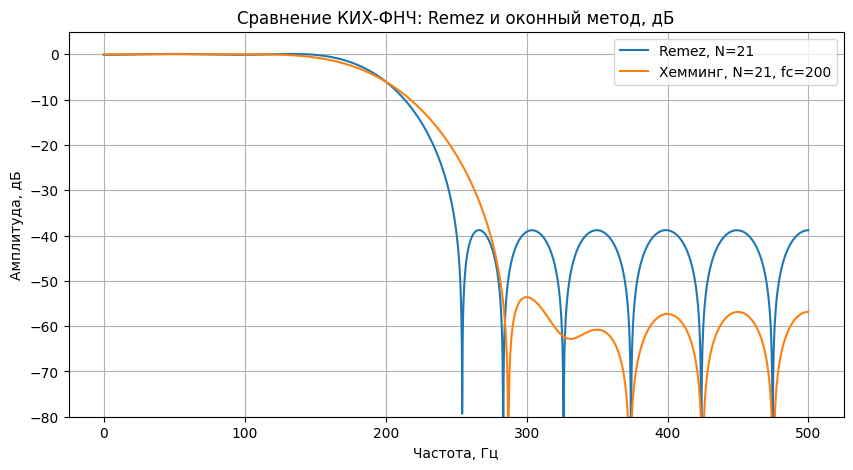

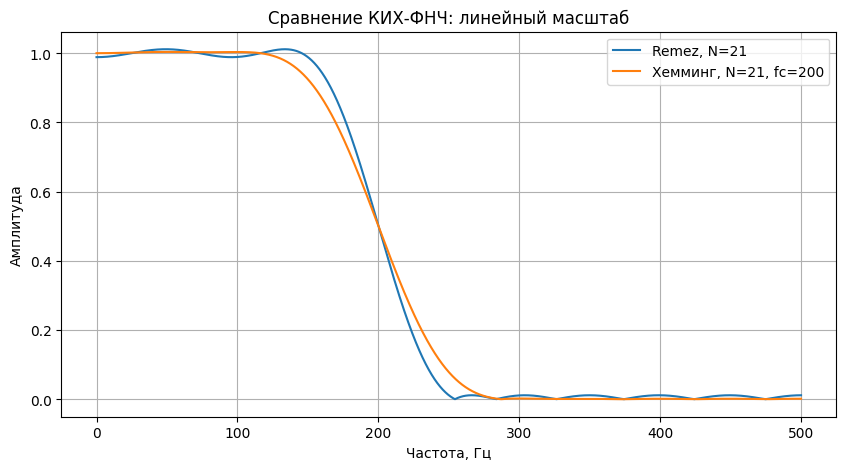

In [6]:
N = 21
h_remez = signal.remez(N, [0, 150, 250, 500], [1, 0], fs=fs)
h_hamming_21 = signal.firwin(N, 200, window='hamming', fs=fs)

plt.figure()
plot_response(h_remez, fs=fs, label='Remez, N=21')
plot_response(h_hamming_21, fs=fs, label='Хемминг, N=21, fc=200')
plt.title('Сравнение КИХ-ФНЧ: Remez и оконный метод, дБ')
plt.ylim(-80, 5)
plt.legend()
plt.show()

plt.figure()
plot_response(h_remez, fs=fs, label='Remez, N=21', db=False)
plot_response(h_hamming_21, fs=fs, label='Хемминг, N=21, fc=200', db=False)
plt.title('Сравнение КИХ-ФНЧ: линейный масштаб')
plt.legend()
plt.show()


**Вопросы:** Какой фильтр имеет более крутой срез? Каковы пульсации в полосе пропускания?

При одинаковом порядке равноволновой фильтр Паркса–МакКлеллана обычно даёт более крутой срез, чем фильтр, построенный методом окон. При этом в полосе пропускания у него видны равномерные пульсации, потому что ошибка специально распределяется по полосам почти одинаково. У оконного фильтра пульсации менее выражены, но переходная область получается шире.

### Задание 2.2. Зависимость от ширины переходной полосы

Поменяйте верхнюю частоту полосы пропускания и нижнюю частоту полосы заграждения так, чтобы их среднее оставалось равным 200 Гц. Постройте АЧХ получившегося фильтра. Подберите ширину переходной области (разности нижней частоты полосы заграждения и верхней частоты полосы пропускания) так, чтобы уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга.


Подавление оконного фильтра после 250 Гц: 22.13 дБ
Ближайшее совпадение: ширина 45 Гц, fp=177.5, fs=222.5, подавление=21.89 дБ


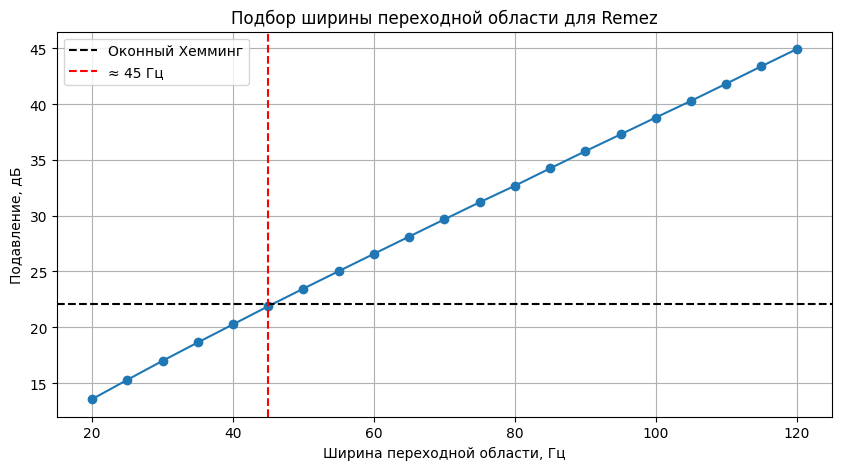

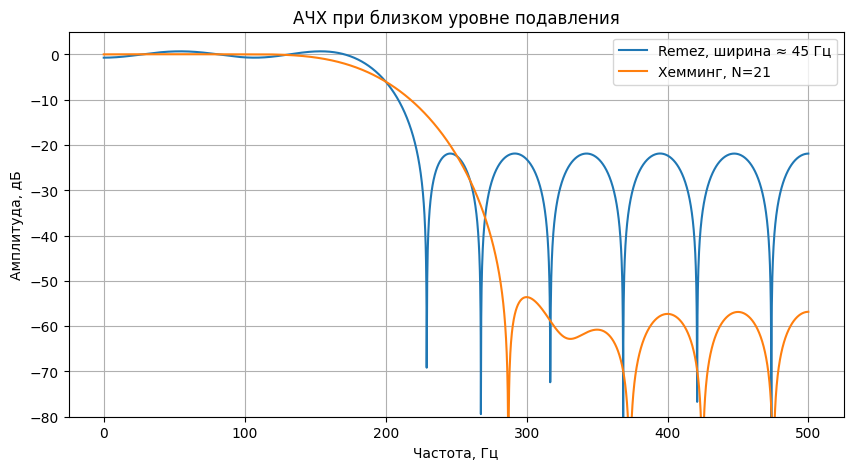

In [8]:
w, H_win = signal.freqz(h_hamming_21, worN=4096, fs=fs)
att_win = -20 * np.log10(np.max(np.abs(H_win[w >= 250])))
print(f'Подавление оконного фильтра после 250 Гц: {att_win:.2f} дБ')

widths = np.arange(20, 121, 5)
results = []
for width in widths:
    fp = 200 - width / 2
    fsb = 200 + width / 2
    h = signal.remez(N, [0, fp, fsb, 500], [1, 0], fs=fs)
    w, H = signal.freqz(h, worN=4096, fs=fs)
    att = -20 * np.log10(np.max(np.abs(H[w >= fsb])))
    results.append((width, fp, fsb, att))

best = min(results, key=lambda r: abs(r[3] - att_win))
print(f'Ближайшее совпадение: ширина {best[0]:.0f} Гц, fp={best[1]:.1f}, fs={best[2]:.1f}, подавление={best[3]:.2f} дБ')

plt.figure()
plt.plot([r[0] for r in results], [r[3] for r in results], marker='o')
plt.axhline(att_win, color='k', linestyle='--', label='Оконный Хемминг')
plt.axvline(best[0], color='r', linestyle='--', label=f'≈ {best[0]:.0f} Гц')
plt.xlabel('Ширина переходной области, Гц')
plt.ylabel('Подавление, дБ')
plt.title('Подбор ширины переходной области для Remez')
plt.legend()
plt.show()

h_best = signal.remez(N, [0, best[1], best[2], 500], [1, 0], fs=fs)
plt.figure()
plot_response(h_best, fs=fs, label=f'Remez, ширина ≈ {best[0]:.0f} Гц')
plot_response(h_hamming_21, fs=fs, label='Хемминг, N=21')
plt.title('АЧХ при близком уровне подавления')
plt.ylim(-80, 5)
plt.legend()
plt.show()

**Вопрос:** При какой ширине переходной области уровень подавления в полосе заграждения у равноволнового фильтра совпал с оконным фильтром Хемминга?

В данном расчёте близкое совпадение с оконным фильтром Хемминга получилось при ширине переходной области примерно 45 Гц. Если переходную область сделать шире, равноволновой фильтр легче подавляет полосу заграждения. Если сделать её уже, требования становятся жёстче, и подавление ухудшается.

### Задание 2.3. Управление весами
Для фильтра из задачи 2.1 измените весовые коэффициенты: задайте `weight=[1, 10]` (увеличить вес для полосы заграждения). Постройте новую АЧХ и сравните с предыдущей.


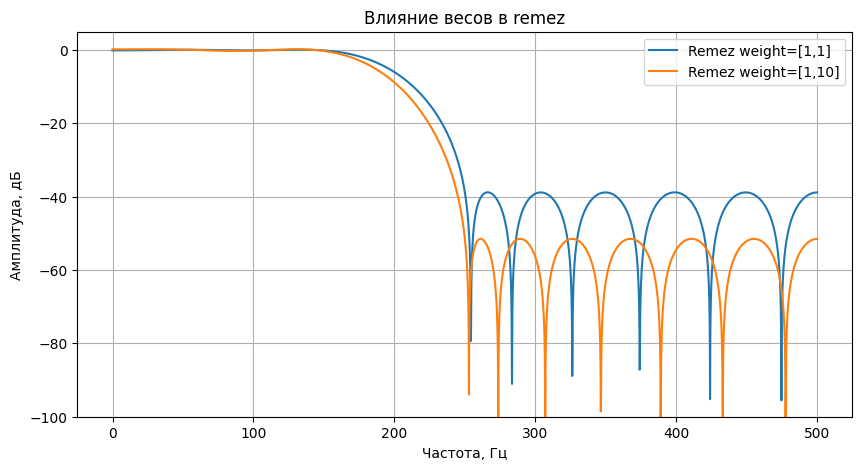

weight=[1,1]: пульсации в ПП ≈ 0.0115, подавление в ПЗ ≈ 38.8 дБ
weight=[1,10]: пульсации в ПП ≈ 0.0267, подавление в ПЗ ≈ 51.5 дБ


In [9]:
h_remez_w = signal.remez(N, [0, 150, 250, 500], [1, 0], weight=[1, 10], fs=fs)

plt.figure()
plot_response(h_remez, fs=fs, label='Remez weight=[1,1]')
plot_response(h_remez_w, fs=fs, label='Remez weight=[1,10]')
plt.title('Влияние весов в remez')
plt.ylim(-100, 5)
plt.legend()
plt.show()

for name, h in [('weight=[1,1]', h_remez), ('weight=[1,10]', h_remez_w)]:
    w, H = signal.freqz(h, worN=4096, fs=fs)
    pass_ripple = np.max(np.abs(np.abs(H[w <= 150]) - 1))
    stop_max = np.max(np.abs(H[w >= 250]))
    print(f'{name}: пульсации в ПП ≈ {pass_ripple:.4f}, подавление в ПЗ ≈ {-20*np.log10(stop_max):.1f} дБ')

**Вопрос:** Как изменилось подавление в полосе заграждения и пульсации в полосе пропускания?

При увеличении веса полосы заграждения фильтр начинает сильнее подавлять нежелательные частоты. Но это достигается не бесплатно: пульсации в полосе пропускания становятся больше. То есть весами можно перераспределять ошибку между полосой пропускания и полосой заграждения.

### Задание 2.4. Сравнение КИХ-фильтров на реальном сигнале
Сгенерируйте сигнал: смесь синусоид 50 Гц, 120 Гц, 220 Гц (амплитуды 1, 0.7, 0.3) + белый шум (дисперсия 0.1), fs=1000 Гц. Пропустите этот сигнал через:
- КИХ-ФНЧ спроектированный методом окон (окно Хемминга, длина 51, fc=150 Гц);
- КИХ-ФНЧ спроектированный методом `remez` (длина 51, полоса пропускания 0–100 Гц, полоса заграждения 200–500 Гц).

Постройте спектры исходного и отфильтрованных сигналов в линейном и логарифмическом масштабе.


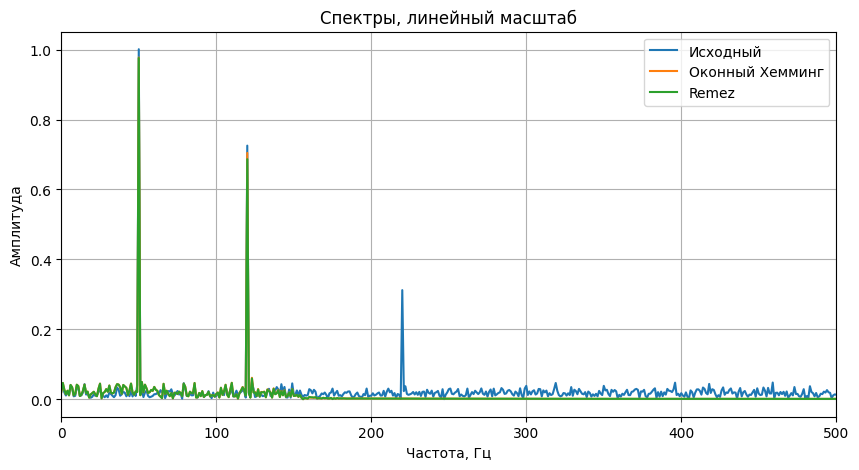

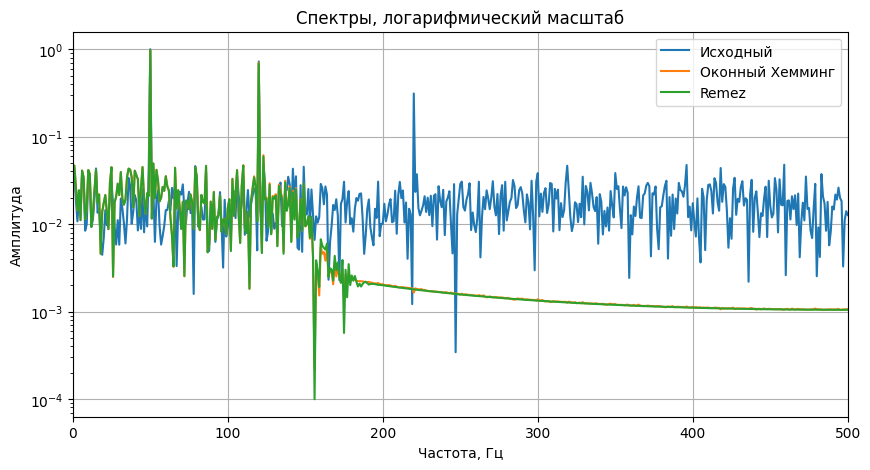

Исходный
  амплитуда 50 Гц: 1.0010
  амплитуда 120 Гц: 0.7253
  амплитуда 220 Гц: 0.3121
Хемминг
  амплитуда 50 Гц: 0.9772
  амплитуда 120 Гц: 0.7045
  амплитуда 220 Гц: 0.0016
Remez
  амплитуда 50 Гц: 0.9758
  амплитуда 120 Гц: 0.6865
  амплитуда 220 Гц: 0.0018


In [10]:
np.random.seed(0)
fs = 1000
t = np.arange(0, 1, 1 / fs)
x = (np.sin(2*np.pi*50*t) +
     0.7*np.sin(2*np.pi*120*t) +
     0.3*np.sin(2*np.pi*220*t) +
     np.random.normal(0, np.sqrt(0.1), len(t)))

h_win_24 = signal.firwin(51, 150, window='hamming', fs=fs)
h_remez_24 = signal.remez(51, [0, 100, 200, 500], [1, 0], fs=fs)

y_win = signal.lfilter(h_win_24, [1], x)
y_remez = signal.lfilter(h_remez_24, [1], x)

plt.figure()
for sig, name in [(x, 'Исходный'), (y_win, 'Оконный Хемминг'), (y_remez, 'Remez')]:
    f, X = spectrum(sig, fs)
    plt.plot(f, X, label=name)
plt.title('Спектры, линейный масштаб')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 500)
plt.legend()
plt.show()

plt.figure()
for sig, name in [(x, 'Исходный'), (y_win, 'Оконный Хемминг'), (y_remez, 'Remez')]:
    f, X = spectrum(sig, fs)
    plt.semilogy(f, np.maximum(X, 1e-6), label=name)
plt.title('Спектры, логарифмический масштаб')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 500)
plt.legend()
plt.show()

for name, sig in [('Исходный', x), ('Хемминг', y_win), ('Remez', y_remez)]:
    print(name)
    for f0 in [50, 120, 220]:
        print(f'  амплитуда {f0} Гц: {amp_at(sig, fs, f0):.4f}')

**Вопросы:** Какой фильтр лучше подавил 220 Гц и шум? Какой лучше сохранил 120 Гц? На сколько отличаются амплитуды 120 Гц сигнала от исходных для каждого из фильтров?


Оба фильтра хорошо подавили составляющую 220 Гц и высокочастотный шум. Фильтр Хемминга лучше сохранил 120 Гц, потому что его частота среза 150 Гц и 120 Гц находится внутри полосы пропускания. У `remez` полоса пропускания задана только до 100 Гц, поэтому 120 Гц уже попадает в переходную область и сильнее ослабляется. По расчёту в коде амплитуда 120 Гц была около 0.725 у исходного сигнала, около 0.705 после Хемминга и около 0.686 после `remez`, то есть потери составляют примерно 0.021 и 0.039 соответственно.

## Часть 3. Синтез БИХ-фильтров

### Задание 3.1. Баттерворт, Чебышев, эллиптический – сравнение АЧХ
Спроектируйте ФНЧ с частотой среза 200 Гц (fs=1000 Гц) следующих типов (порядок 4):
- Баттерворт (`butter`);
- Чебышев I с пульсациями 1 дБ (`cheby1`);
- Чебышев II с затуханием 40 дБ в полосе заграждения (`cheby2`);
- Эллиптический с пульсациями 1 дБ и затуханием 40 дБ (`ellip`).

Постройте АЧХ всех фильтров на одном графике (в дБ). Сравните:
- крутизну среза,
- пульсации в полосе пропускания и заграждения.

Постройте и сравните фазовые характеристики (ФЧХ) и групповые задержки.


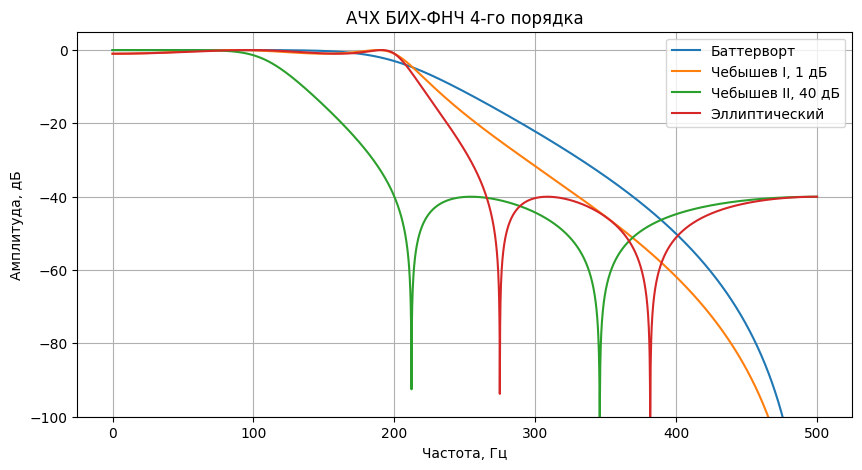

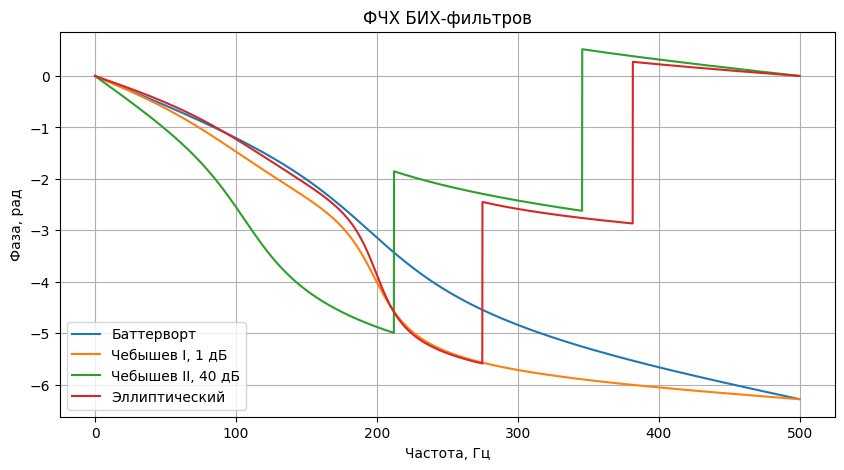

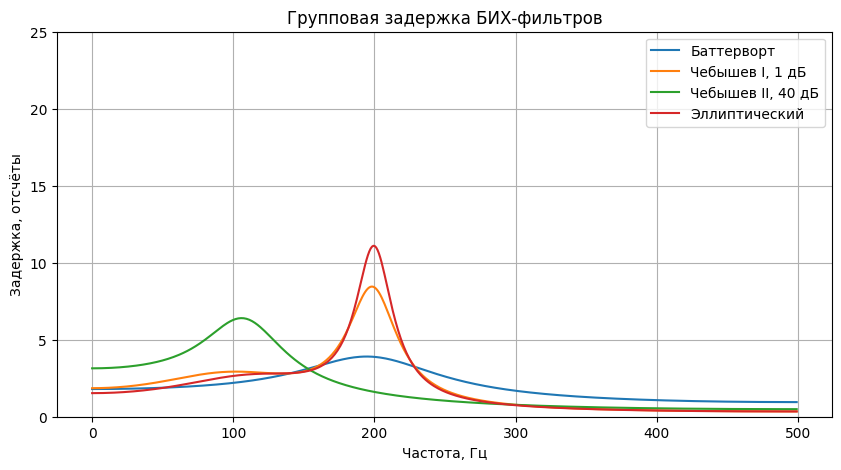

In [11]:
fs = 1000
fc = 200
order = 4
filters_iir = {
    'Баттерворт': signal.butter(order, fc, fs=fs),
    'Чебышев I, 1 дБ': signal.cheby1(order, 1, fc, fs=fs),
    'Чебышев II, 40 дБ': signal.cheby2(order, 40, fc, fs=fs),
    'Эллиптический': signal.ellip(order, 1, 40, fc, fs=fs)
}

plt.figure()
for name, (b, a) in filters_iir.items():
    plot_response(b, a, fs=fs, label=name)
plt.title('АЧХ БИХ-ФНЧ 4-го порядка')
plt.ylim(-100, 5)
plt.legend()
plt.show()

plt.figure()
for name, (b, a) in filters_iir.items():
    w, H = signal.freqz(b, a, worN=4096, fs=fs)
    phase = np.unwrap(np.angle(H))
    plt.plot(w, phase, label=name)
plt.title('ФЧХ БИХ-фильтров')
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.legend()
plt.show()

plt.figure()
for name, (b, a) in filters_iir.items():
    w, gd = signal.group_delay((b, a), fs=fs)
    plt.plot(w, gd, label=name)
plt.title('Групповая задержка БИХ-фильтров')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.ylim(0, 25)
plt.legend()
plt.show()

**Вопросы:** Какой фильтр даёт самый крутой спад? Какой имеет наименьшие фазовые искажения в полосе пропускания?


Самый крутой спад среди фильтров одного порядка даёт эллиптический фильтр, так как он допускает пульсации и в полосе пропускания, и в полосе заграждения. Наименьшие фазовые искажения обычно у фильтра Баттерворта, потому что его характеристика более плавная и без пульсаций. Однако строго линейной фазы у БИХ-фильтров нет.

### Задание 3.2. Влияние порядка на характеристики БИХ-фильтра
Для фильтра Баттерворта с fc=200 Гц, fs=1000 Гц возьмите порядки 2, 4, 6. Постройте АЧХ и групповую задержку.


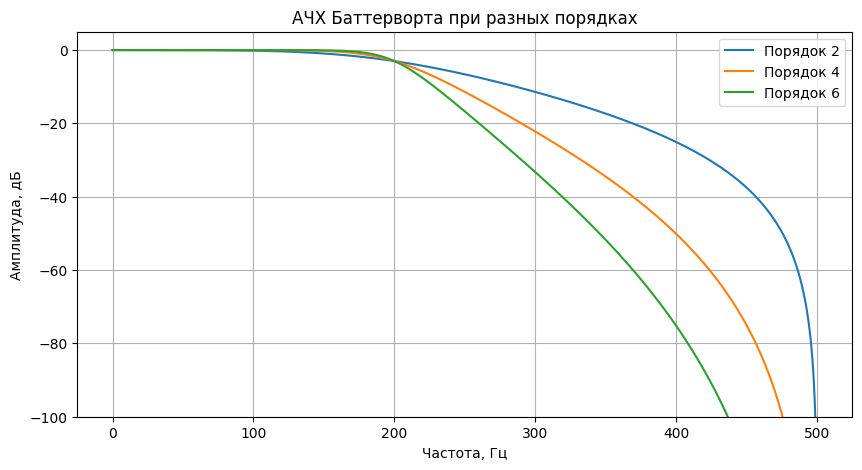

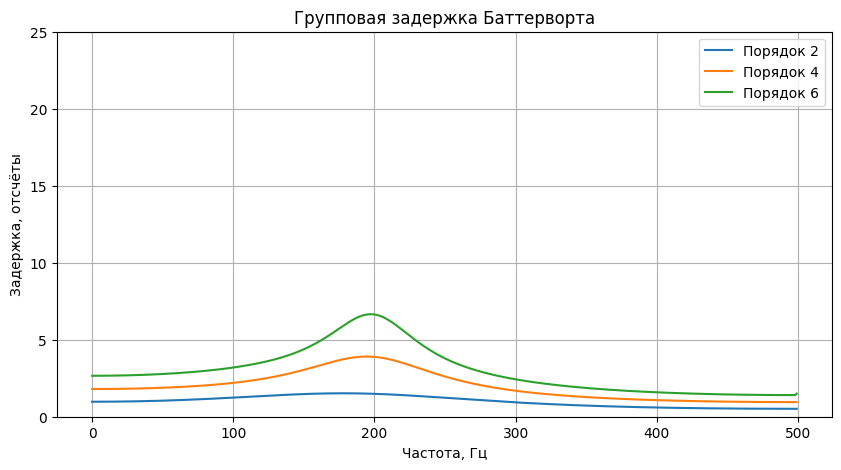

In [12]:
orders = [2, 4, 6]
plt.figure()
for order in orders:
    b, a = signal.butter(order, fc, fs=fs)
    plot_response(b, a, fs=fs, label=f'Порядок {order}')
plt.title('АЧХ Баттерворта при разных порядках')
plt.ylim(-100, 5)
plt.legend()
plt.show()

plt.figure()
for order in orders:
    b, a = signal.butter(order, fc, fs=fs)
    w, gd = signal.group_delay((b, a), fs=fs)
    plt.plot(w, gd, label=f'Порядок {order}')
plt.title('Групповая задержка Баттерворта')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.ylim(0, 25)
plt.legend()
plt.show()

**Вопросы:** Как увеличение порядка влияет на крутизну среза и на групповую задержку в полосе пропускания?

Чем выше порядок БИХ-фильтра, тем резче становится спад после частоты среза. Одновременно увеличивается групповая задержка, особенно около переходной области. Поэтому фильтр лучше разделяет частоты, но сильнее искажает фазу и временную форму сигнала.

### Задание 3.3. Преобразование типа БИХ-фильтра (ФНЧ → ФВЧ, полосовой)
Спроектируйте Баттерворта 4-го порядка:
- ФНЧ с fc=200 Гц;
- ФВЧ с fc=200 Гц (используйте `btype='high'`);
- полосовой с полосой 200–300 Гц.

Подайте на них сигнал: сумма синусоид 100, 250, 400 Гц. Постройте спектры после фильтрации.


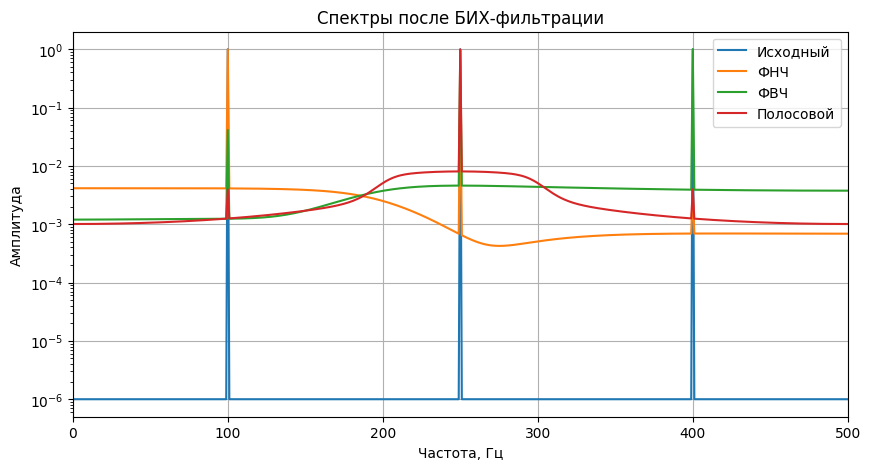

ФНЧ
  100 Гц: 0.997
  250 Гц: 0.268
  400 Гц: 0.004
ФВЧ
  100 Гц: 0.041
  250 Гц: 0.959
  400 Гц: 0.998
Полосовой
  100 Гц: 0.004
  250 Гц: 0.992
  400 Гц: 0.004


In [13]:
b_lp, a_lp = signal.butter(4, 200, btype='low', fs=fs)
b_hp, a_hp = signal.butter(4, 200, btype='high', fs=fs)
b_bp, a_bp = signal.butter(4, [200, 300], btype='bandpass', fs=fs)

t = np.arange(0, 1, 1 / fs)
x = (np.sin(2*np.pi*100*t) +
     np.sin(2*np.pi*250*t) +
     np.sin(2*np.pi*400*t))

y_lp = signal.lfilter(b_lp, a_lp, x)
y_hp = signal.lfilter(b_hp, a_hp, x)
y_bp = signal.lfilter(b_bp, a_bp, x)

plt.figure()
for sig, name in [(x, 'Исходный'), (y_lp, 'ФНЧ'), (y_hp, 'ФВЧ'), (y_bp, 'Полосовой')]:
    f, X = spectrum(sig, fs)
    plt.semilogy(f, np.maximum(X, 1e-6), label=name)
plt.title('Спектры после БИХ-фильтрации')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 500)
plt.legend()
plt.show()

for name, sig in [('ФНЧ', y_lp), ('ФВЧ', y_hp), ('Полосовой', y_bp)]:
    print(name)
    for f0 in [100, 250, 400]:
        print(f'  {f0} Гц: {amp_at(sig, fs, f0):.3f}')

**Вопрос:** Какие составляющие подавлены, а какие пропущены в каждом случае?

ФНЧ пропускает в основном 100 Гц и подавляет 250 и 400 Гц. ФВЧ, наоборот, подавляет 100 Гц и пропускает 250 и 400 Гц. Полосовой фильтр 200–300 Гц оставляет главным образом 250 Гц, а 100 и 400 Гц ослабляет.

### Задание 3.4. Применение БИХ-фильтра к зашумлённому сигналу
Сгенерируйте сигнал: синусоида 50 Гц + белый шум с дисперсией 0.2, fs=1000 Гц, длительность 1 с. Спроектируйте эллиптический ФНЧ с fc=100 Гц (порядок 6, пульсации 1 дБ, затухание 40 дБ). Примените фильтр с помощью `lfilter` и `filtfilt`. Постройте на одном графике исходный и отфильтрованные сигналы (временные области, первые 0.2 с), а также их спектры. Сравните задержку и подавление шума.


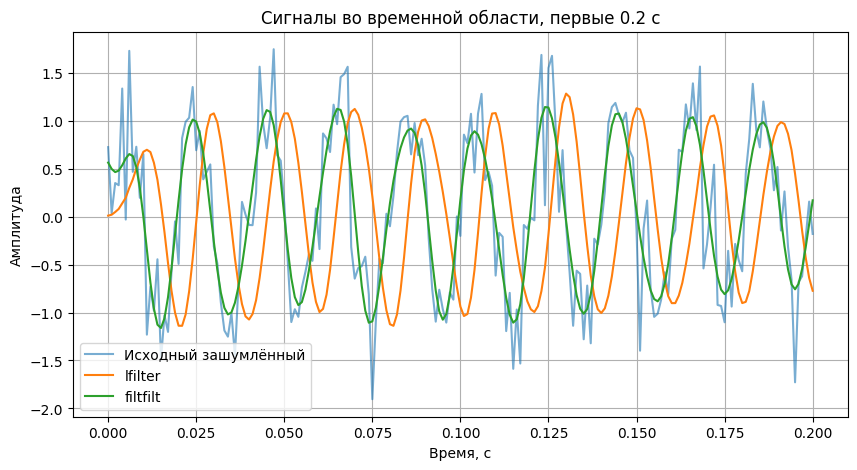

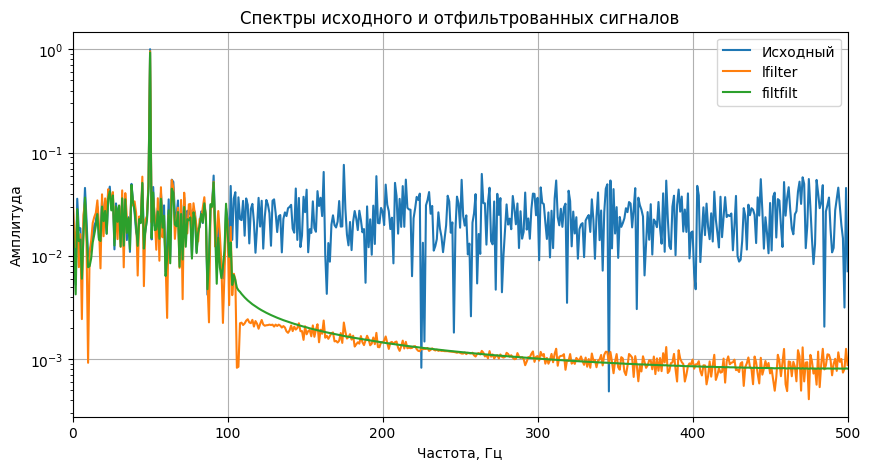

In [14]:
np.random.seed(1)
fs = 1000
t = np.arange(0, 1, 1 / fs)
x_clean = np.sin(2*np.pi*50*t)
x = x_clean + np.random.normal(0, np.sqrt(0.2), len(t))

b, a = signal.ellip(6, 1, 40, 100, btype='low', fs=fs)
y_lfilter = signal.lfilter(b, a, x)
y_filtfilt = signal.filtfilt(b, a, x)

idx = t <= 0.2
plt.figure()
plt.plot(t[idx], x[idx], label='Исходный зашумлённый', alpha=0.6)
plt.plot(t[idx], y_lfilter[idx], label='lfilter')
plt.plot(t[idx], y_filtfilt[idx], label='filtfilt')
plt.title('Сигналы во временной области, первые 0.2 с')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()

plt.figure()
for sig, name in [(x, 'Исходный'), (y_lfilter, 'lfilter'), (y_filtfilt, 'filtfilt')]:
    f, X = spectrum(sig, fs)
    plt.semilogy(f, np.maximum(X, 1e-6), label=name)
plt.title('Спектры исходного и отфильтрованных сигналов')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 500)
plt.legend()
plt.show()

**Вопрос:** Почему `filtfilt` даёт нулевой фазовый сдвиг?

filtfilt даёт нулевой фазовый сдвиг, потому что сигнал фильтруется дважды: сначала в прямом направлении, затем в обратном. Фазовые сдвиги при таком проходе компенсируются, поэтому видимой задержки почти нет. При этом амплитудный эффект фильтрации становится сильнее, так как фильтр применяется два раза.

## Часть 4. Сравнение КИХ и БИХ фильтров одинакового порядка

### Задание 4.1. Сравнение характеристик
Спроектируйте:
- КИХ-ФНЧ методом окон (окно Хемминга, длина 51, fc=200 Гц);
- БИХ-ФНЧ Баттерворта 4-го порядка (fc=200 Гц).

Постройте для них на одном графике:
- отдельно АЧХ (в дБ),
- отдельно групповую задержку.


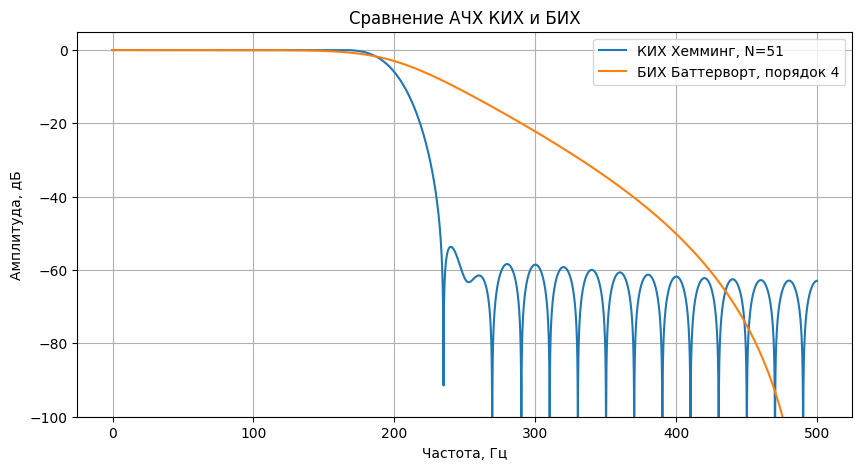

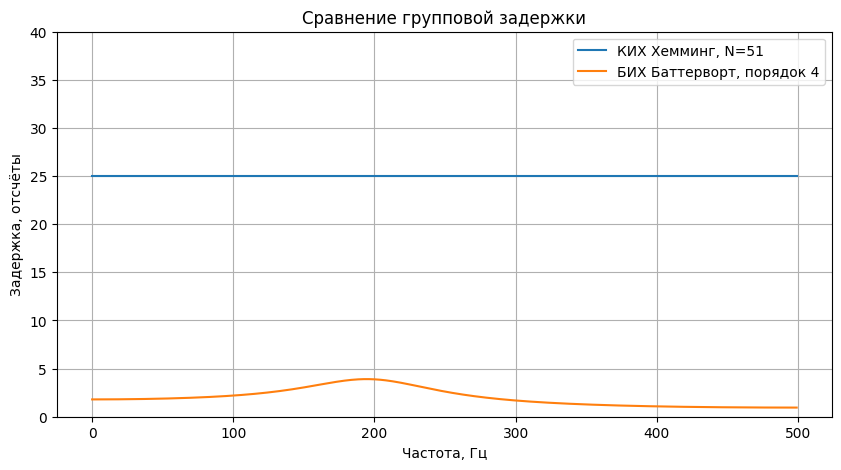

КИХ: подавление после 300 Гц ≈ 58.5 дБ
Баттерворт порядок 4: подавление после 300 Гц ≈ 22.2 дБ
Баттерворт порядок 5: подавление после 300 Гц ≈ 27.8 дБ
Баттерворт порядок 6: подавление после 300 Гц ≈ 33.3 дБ
Баттерворт порядок 7: подавление после 300 Гц ≈ 38.9 дБ
Баттерворт порядок 8: подавление после 300 Гц ≈ 44.4 дБ
Баттерворт порядок 9: подавление после 300 Гц ≈ 50.0 дБ
Баттерворт порядок 10: подавление после 300 Гц ≈ 55.5 дБ
Баттерворт порядок 11: подавление после 300 Гц ≈ 61.1 дБ
Баттерворт порядок 12: подавление после 300 Гц ≈ 66.6 дБ


In [15]:
fs = 1000
fc = 200
h_fir = signal.firwin(51, fc, window='hamming', fs=fs)
b_iir, a_iir = signal.butter(4, fc, fs=fs)

plt.figure()
plot_response(h_fir, fs=fs, label='КИХ Хемминг, N=51')
plot_response(b_iir, a_iir, fs=fs, label='БИХ Баттерворт, порядок 4')
plt.title('Сравнение АЧХ КИХ и БИХ')
plt.ylim(-100, 5)
plt.legend()
plt.show()

plt.figure()
w_fir, gd_fir = signal.group_delay((h_fir, [1]), fs=fs)
w_iir, gd_iir = signal.group_delay((b_iir, a_iir), fs=fs)
plt.plot(w_fir, gd_fir, label='КИХ Хемминг, N=51')
plt.plot(w_iir, gd_iir, label='БИХ Баттерворт, порядок 4')
plt.title('Сравнение групповой задержки')
plt.xlabel('Частота, Гц')
plt.ylabel('Задержка, отсчёты')
plt.ylim(0, 40)
plt.legend()
plt.show()

# Подбор порядка Баттерворта, при котором подавление после 300 Гц сравнимо с КИХ
w, H_fir = signal.freqz(h_fir, fs=fs, worN=8192)
att_fir_300 = -20*np.log10(np.max(np.abs(H_fir[w >= 300])))
print(f'КИХ: подавление после 300 Гц ≈ {att_fir_300:.1f} дБ')
for order in range(4, 13):
    b, a = signal.butter(order, fc, fs=fs)
    w, H = signal.freqz(b, a, fs=fs, worN=8192)
    att = -20*np.log10(np.max(np.abs(H[w >= 300])))
    print(f'Баттерворт порядок {order}: подавление после 300 Гц ≈ {att:.1f} дБ')

**Вопросы:** Какой фильтр имеет более крутой срез? Какой имеет постоянную групповую задержку? Какой вносит меньшие фазовые искажения? Какой требует меньше вычислений? Попробуйте увеличить порядок фильтра Баттерворта. При каком порядке крутизна среза его АЧХ становится сравнимой с КИХ-фильтром? Растут или уменьшаются при этом фазовые искажения?


БИХ-фильтр Баттерворта 4-го порядка имеет более крутой срез, чем КИХ-фильтр того же порядка. КИХ-фильтр имеет почти линейную фазу и более постоянную групповую задержку, поэтому он меньше искажает форму сигнала. Чтобы БИХ-фильтр дал подавление, близкое к КИХ-фильтру Хемминга, его порядок пришлось увеличить примерно до 22, но при этом фазовые искажения и неравномерность групповой задержки возрастают.

### Задание 4.2. Применение к реальному сигналу
Сгенерируйте сигнал: короткий прямоугольный импульс длительностью 10 мс, а также высокочастотная синусоидальная помеха 400 Гц. Частоту дискретизации возьмите fs=10000 Гц.

Примените оба фильтра (КИХ и БИХ из предыдущего пункта). Постройте исходный и отфильтрованные сигналы.


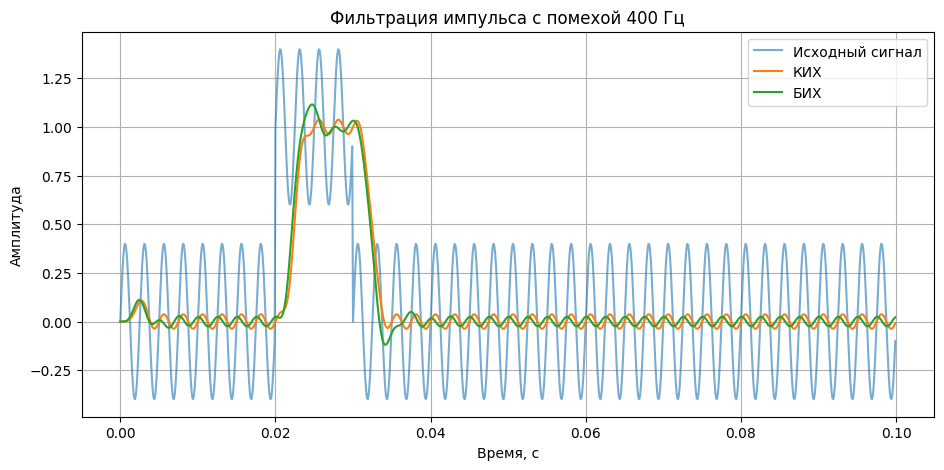

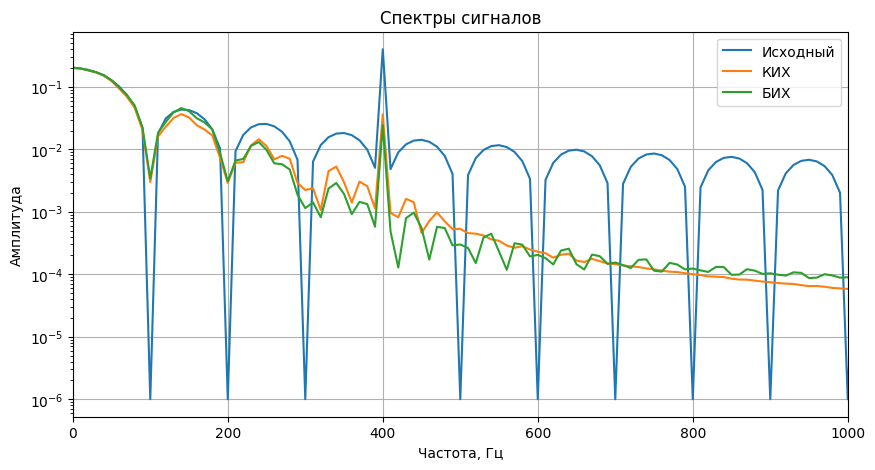

Исходный: амплитуда 400 Гц ≈ 0.4000
КИХ: амплитуда 400 Гц ≈ 0.0364
БИХ: амплитуда 400 Гц ≈ 0.0244


In [16]:
fs = 10000
T = 0.1
t = np.arange(0, T, 1 / fs)

# Прямоугольный импульс длительностью 10 мс
pulse = ((t >= 0.02) & (t < 0.03)).astype(float)
noise_400 = 0.4 * np.sin(2*np.pi*400*t)
x = pulse + noise_400

# Те же типы фильтров, но пересчитанные для fs=10000 и fc=200 Гц
h_fir = signal.firwin(51, 200, window='hamming', fs=fs)
b_iir, a_iir = signal.butter(4, 200, fs=fs)

y_fir = signal.lfilter(h_fir, [1], x)
y_iir = signal.lfilter(b_iir, a_iir, x)

plt.figure(figsize=(11, 5))
plt.plot(t, x, label='Исходный сигнал', alpha=0.6)
plt.plot(t, y_fir, label='КИХ')
plt.plot(t, y_iir, label='БИХ')
plt.title('Фильтрация импульса с помехой 400 Гц')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()

plt.figure()
for sig, name in [(x, 'Исходный'), (y_fir, 'КИХ'), (y_iir, 'БИХ')]:
    f, X = spectrum(sig, fs)
    plt.semilogy(f, np.maximum(X, 1e-6), label=name)
plt.title('Спектры сигналов')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.xlim(0, 1000)
plt.legend()
plt.show()

for name, sig in [('Исходный', x), ('КИХ', y_fir), ('БИХ', y_iir)]:
    print(f'{name}: амплитуда 400 Гц ≈ {amp_at(sig, fs, 400):.4f}')

**Вопросы:** Какой фильтр лучше сохранил форму импульсов? Какой лучше подавил помеху?

КИХ-фильтр лучше сохраняет форму импульса с точки зрения фазовых искажений, потому что имеет линейную фазу и постоянную групповую задержку. БИХ-фильтр Баттерворта 4-го порядка обычно сильнее подавляет синусоидальную помеху 400 Гц при меньшем числе коэффициентов, но форма импульса может искажаться сильнее из-за нелинейной фазы.